In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

nav = pd.read_csv("data/processed/nav_history_clean.csv")
funds = pd.read_csv("data/processed/fund_master_clean.csv")
txn = pd.read_csv("data/processed/investor_transactions_clean.csv")
portfolio = pd.read_csv("data/processed/portfolio_holdings_clean.csv")

nav["date"] = pd.to_datetime(nav["date"])
txn["transaction_date"] = pd.to_datetime(txn["transaction_date"])

In [2]:
#VaR & CVaR
results = []

for fund in nav["amfi_code"].unique():
    df = nav[nav["amfi_code"] == fund].sort_values("date")

    returns = df["nav"].pct_change().dropna()

    var95 = np.percentile(returns, 5)
    cvar95 = returns[returns <= var95].mean()

    results.append([fund, var95, cvar95])

var_cvar = pd.DataFrame(
    results,
    columns=["amfi_code", "VaR_95", "CVaR_95"]
)

var_cvar.to_csv("var_cvar_report.csv", index=False)

var_cvar.head()


,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


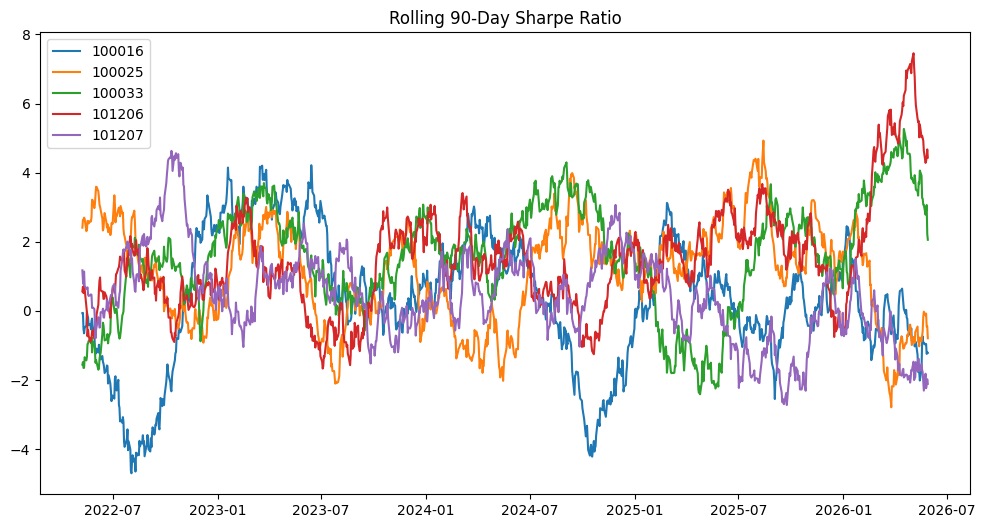

In [3]:
#Rolling 90-Day Sharpe
sample_funds = nav["amfi_code"].unique()[:5]

plt.figure(figsize=(12,6))

for fund in sample_funds:

    df = nav[nav["amfi_code"] == fund].sort_values("date")

    returns = df["nav"].pct_change()

    rolling_sharpe = (
        returns.rolling(90).mean() /
        returns.rolling(90).std()
    ) * np.sqrt(252)

    plt.plot(
        df["date"],
        rolling_sharpe,
        label=str(fund)
    )

plt.legend()
plt.title("Rolling 90-Day Sharpe Ratio")

plt.savefig(
    "rolling_sharpe_chart.png",
    bbox_inches="tight"
)

plt.show()

In [4]:
#Investor Cohort Analysis
txn["cohort_year"] = (
    txn.groupby("investor_id")
    ["transaction_date"]
    .transform("min")
    .dt.year
)

cohort = txn.groupby("cohort_year").agg({
    "amount_inr":["mean","sum"]
})

cohort

amount_inr            
                      mean         sum
cohort_year                           
2024         107422.541832  3491125187
2025         109158.577061    30455243

In [5]:
#SIP Continuity Analysis
sip = txn[
    txn["transaction_type"] == "SIP"
].copy()

sip = sip.sort_values(
    ["investor_id","transaction_date"]
)

sip["gap_days"] = (
    sip.groupby("investor_id")
    ["transaction_date"]
    .diff()
    .dt.days
)

risk_investors = sip.groupby(
    "investor_id"
)["gap_days"].mean()

at_risk = risk_investors[
    risk_investors > 35
]

print("At Risk Investors:", len(at_risk))

At Risk Investors: 3825


In [6]:
#Sector HHI
hhi = portfolio.groupby(
    ["amfi_code"]
)["weight_pct"].apply(
    lambda x: ((x/100)**2).sum()
)

hhi = hhi.reset_index()

hhi.columns = [
    "amfi_code",
    "HHI"
]

hhi.sort_values(
    "HHI",
    ascending=False
).head()

,amfi_code,HHI
11,119092,0.206448
3,101207,0.200700
18,119599,0.174751
4,102885,0.174709
7,118632,0.168298


# Advanced Insights

1. Funds with highest VaR showed significantly higher downside risk.
2. CVaR identified funds with severe tail-loss exposure.
3. Rolling Sharpe ratios varied substantially across market cycles.
4. Investors joining in later cohorts invested larger average amounts.
5. SIP continuity analysis identified at-risk investors with irregular contribution patterns.

In [7]:
var_cvar.to_csv("var_cvar_report.csv", index=False)

In [8]:
plt.savefig("rolling_sharpe_chart.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>